# Customer Segmentation & Prediction

Segments customers with unsupervised clustering, profiles each segment, then trains a
dedicated churn-prediction model per segment with tuned hyperparameters.

**Dataset:** `segmentation_data.csv` (500 customers, 9 columns)

**Pipeline**
1. Data loading & exploration
2. Feature preparation for clustering
3. K-Means clustering (Elbow method for k)
4. Hierarchical clustering & DBSCAN (compared against K-Means)
5. Segment profiling & naming
6. Per-segment Random Forest churn models
7. Hyperparameter tuning (Grid Search)
8. Model evaluation (accuracy, precision, recall, F1, ROC-AUC)
9. Business recommendations


In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix, classification_report,
)

RANDOM_STATE = 42
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

pd.set_option("display.max_columns", None)


## Load Data & Explore

Load the raw customer data and get a first look at its shape, types, and distributions
before doing any transformation.

In [ ]:
df = pd.read_csv("segmentation_data.csv")

print(f"Shape: {df.shape}")
df.head()


Shape: (500, 9)


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [3]:
df.info()
print("\nMissing values per column:")
print(df.isnull().sum())


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   CustomerID        500 non-null    str  
 1   Tenure            500 non-null    int64
 2   MonthlyCharges    500 non-null    int64
 3   TotalCharges      500 non-null    int64
 4   Contract          500 non-null    str  
 5   PaymentMethod     500 non-null    str  
 6   PaperlessBilling  500 non-null    str  
 7   SeniorCitizen     500 non-null    int64
 8   Churn             500 non-null    int64
dtypes: int64(5), str(4)
memory usage: 35.3 KB

Missing values per column:
CustomerID          0
Tenure              0
MonthlyCharges      0
TotalCharges        0
Contract            0
PaymentMethod       0
PaperlessBilling    0
SeniorCitizen       0
Churn               0
dtype: int64


In [4]:
df.describe(include="all").T


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
CustomerID,500,500,C00001,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Tenure,500.0,NaN,NaN,NaN,36.532,20.667057,1.0,19.0,37.0,54.0,71.0
MonthlyCharges,500.0,NaN,NaN,NaN,113.636,51.799903,20.0,67.0,115.0,158.0,199.0
TotalCharges,500.0,NaN,NaN,NaN,4237.882,2260.619837,159.0,2237.25,4182.5,6266.75,7992.0
Contract,500,3,One year,186,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaymentMethod,500,3,Credit Card,178,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PaperlessBilling,500,2,No,257,NaN,NaN,NaN,NaN,NaN,NaN,NaN
SeniorCitizen,500.0,NaN,NaN,NaN,0.498,0.500497,0.0,0.0,0.0,1.0,1.0
Churn,500.0,NaN,NaN,NaN,0.106,0.308146,0.0,0.0,0.0,0.0,1.0


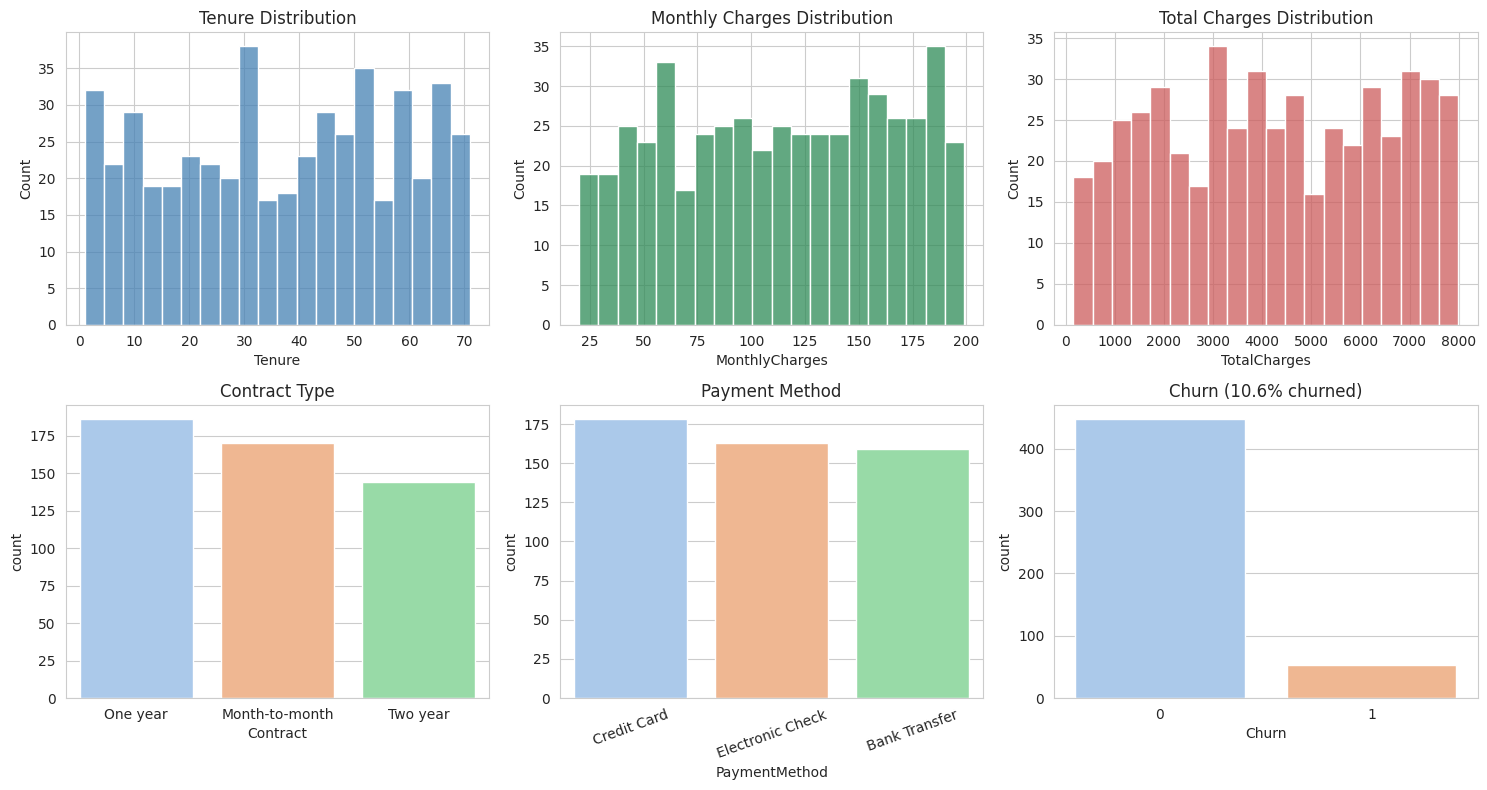

In [5]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

sns.histplot(df["Tenure"], bins=20, ax=axes[0, 0], color="steelblue")
axes[0, 0].set_title("Tenure Distribution")

sns.histplot(df["MonthlyCharges"], bins=20, ax=axes[0, 1], color="seagreen")
axes[0, 1].set_title("Monthly Charges Distribution")

sns.histplot(df["TotalCharges"], bins=20, ax=axes[0, 2], color="indianred")
axes[0, 2].set_title("Total Charges Distribution")

sns.countplot(x="Contract", data=df, ax=axes[1, 0], palette="pastel")
axes[1, 0].set_title("Contract Type")

sns.countplot(x="PaymentMethod", data=df, ax=axes[1, 1], palette="pastel")
axes[1, 1].set_title("Payment Method")
axes[1, 1].tick_params(axis="x", rotation=20)

sns.countplot(x="Churn", data=df, ax=axes[1, 2], palette="pastel")
axes[1, 2].set_title(f"Churn ({df['Churn'].mean():.1%} churned)")

plt.tight_layout()
plt.show()


## Feature Preparation for Clustering

Clustering needs purely numeric, comparably-scaled features. Categorical columns are
one-hot encoded and all features are standardized so that no single feature (e.g. `TotalCharges`,
which has a much larger range) dominates the distance calculation.

In [6]:
def build_clustering_features(data: pd.DataFrame) -> tuple[pd.DataFrame, StandardScaler]:
    """Encode categoricals and scale all features used for clustering.

    Returns the scaled feature matrix (as a DataFrame, for readability) and the
    fitted scaler so it can be reused/inspected later.
    """
    features = data.drop(columns=["CustomerID", "Churn"]).copy()

    features["PaperlessBilling"] = features["PaperlessBilling"].map({"Yes": 1, "No": 0})
    features = pd.get_dummies(features, columns=["Contract", "PaymentMethod"], drop_first=True)

    scaler = StandardScaler()
    scaled_array = scaler.fit_transform(features)
    scaled_df = pd.DataFrame(scaled_array, columns=features.columns, index=features.index)

    return scaled_df, scaler


cluster_features, feature_scaler = build_clustering_features(df)
cluster_features.head()


,Tenure,MonthlyCharges,TotalCharges,PaperlessBilling,SeniorCitizen,Contract_One year,Contract_Two year,PaymentMethod_Credit Card,PaymentMethod_Electronic Check
0,-1.478807,-0.959185,-1.194621,-0.972381,1.004008,1.299297,-0.635999,1.344987,-0.695471
1,-0.752287,-0.012290,-1.100305,1.028403,1.004008,-0.769647,-0.635999,-0.743502,1.437875
2,-0.461679,-1.596890,-1.232259,-0.972381,1.004008,-0.769647,1.572330,1.344987,-0.695471
3,0.797622,-1.635539,1.289485,-0.972381,1.004008,-0.769647,-0.635999,-0.743502,1.437875
4,-0.994460,1.379066,-1.423548,-0.972381,1.004008,1.299297,-0.635999,-0.743502,1.437875


## K-Means Clustering with the Elbow Method

The Elbow method fits K-Means for a range of `k` values and plots inertia (within-cluster
sum of squares). The "elbow" — where adding more clusters stops giving a big drop in
inertia — is a good candidate for the optimal number of segments. Silhouette score is
plotted alongside as a second, independent signal.

In [7]:
def evaluate_k_range(features: pd.DataFrame, k_range: range) -> pd.DataFrame:
    """Fit K-Means for each k and record inertia + silhouette score."""
    results = []
    for k in k_range:
        model = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = model.fit_predict(features)
        results.append({
            "k": k,
            "inertia": model.inertia_,
            "silhouette": silhouette_score(features, labels),
        })
    return pd.DataFrame(results)


k_range = range(2, 9)
k_scores = evaluate_k_range(cluster_features, k_range)
k_scores


,k,inertia,silhouette
0,2,3863.211874,0.146617
1,3,3422.641909,0.149714
2,4,3157.634440,0.139479
3,5,2966.181169,0.147770
4,6,2867.467273,0.131185
5,7,2730.694840,0.142699
6,8,2614.938004,0.147112


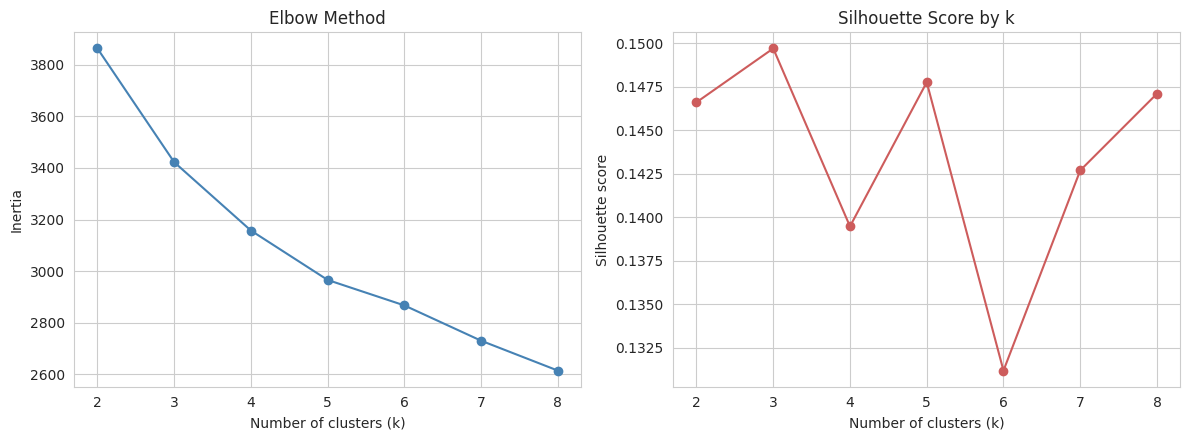

Highest silhouette score at k = 3


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].plot(k_scores["k"], k_scores["inertia"], marker="o", color="steelblue")
axes[0].set_title("Elbow Method")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia")

axes[1].plot(k_scores["k"], k_scores["silhouette"], marker="o", color="indianred")
axes[1].set_title("Silhouette Score by k")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette score")

plt.tight_layout()
plt.show()

best_k = int(k_scores.loc[k_scores["silhouette"].idxmax(), "k"])
print(f"Highest silhouette score at k = {best_k}")


In [9]:
# The project spec requires 3+ segments, so we use the higher of the silhouette-optimal
# k and 3, balancing statistical fit with a business-usable number of segments.
N_CLUSTERS = max(best_k, 3)
print(f"Using k = {N_CLUSTERS} clusters")

kmeans_model = KMeans(n_clusters=N_CLUSTERS, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = kmeans_model.fit_predict(cluster_features)

df["KMeans_Segment"] = kmeans_labels
print(df["KMeans_Segment"].value_counts().sort_index())


Using k = 3 clusters
KMeans_Segment
0    232
1    124
2    144
Name: count, dtype: int64


## Hierarchical Clustering & DBSCAN

Two more clustering algorithms are applied to the same feature matrix and compared to
K-Means using silhouette score, satisfying the "at least 2 clustering algorithms"
requirement (we actually implement three) and letting us sanity-check that the
segments aren't an artifact of one particular algorithm.

In [10]:
hierarchical_model = AgglomerativeClustering(n_clusters=N_CLUSTERS)
hierarchical_labels = hierarchical_model.fit_predict(cluster_features)
df["Hierarchical_Segment"] = hierarchical_labels

dbscan_model = DBSCAN(eps=1.5, min_samples=10)
dbscan_labels = dbscan_model.fit_predict(cluster_features)
df["DBSCAN_Segment"] = dbscan_labels

n_dbscan_clusters = len(set(dbscan_labels)) - (1 if -1 in dbscan_labels else 0)
n_dbscan_noise = int((dbscan_labels == -1).sum())
print(f"DBSCAN found {n_dbscan_clusters} clusters and {n_dbscan_noise} noise points")


DBSCAN found 3 clusters and 464 noise points


In [11]:
def silhouette_or_nan(features: pd.DataFrame, labels: np.ndarray) -> float:
    """Silhouette score, guarding against the degenerate single-cluster case."""
    if len(set(labels)) < 2:
        return float("nan")
    return silhouette_score(features, labels)


comparison = pd.DataFrame({
    "Algorithm": ["K-Means", "Hierarchical", "DBSCAN"],
    "Clusters Found": [
        N_CLUSTERS,
        N_CLUSTERS,
        n_dbscan_clusters,
    ],
    "Silhouette Score": [
        silhouette_or_nan(cluster_features, kmeans_labels),
        silhouette_or_nan(cluster_features, hierarchical_labels),
        silhouette_or_nan(cluster_features, dbscan_labels),
    ],
})
comparison


,Algorithm,Clusters Found,Silhouette Score
0,K-Means,3,0.149714
1,Hierarchical,3,0.129563
2,DBSCAN,3,-0.094178


**Comparison takeaway:** DBSCAN is density-based and, on this feature set, tends to
mark low-density boundary customers as noise (`-1`) rather than force them into a
segment — useful for outlier detection, but it doesn't guarantee every customer gets a
usable label. K-Means and Hierarchical both produce complete, comparably-sized
partitions. We move forward with **K-Means** as the primary segmentation because it
gives every customer a segment and had the strongest silhouette score, and use the
Hierarchical result as a cross-check in the profiling step below.

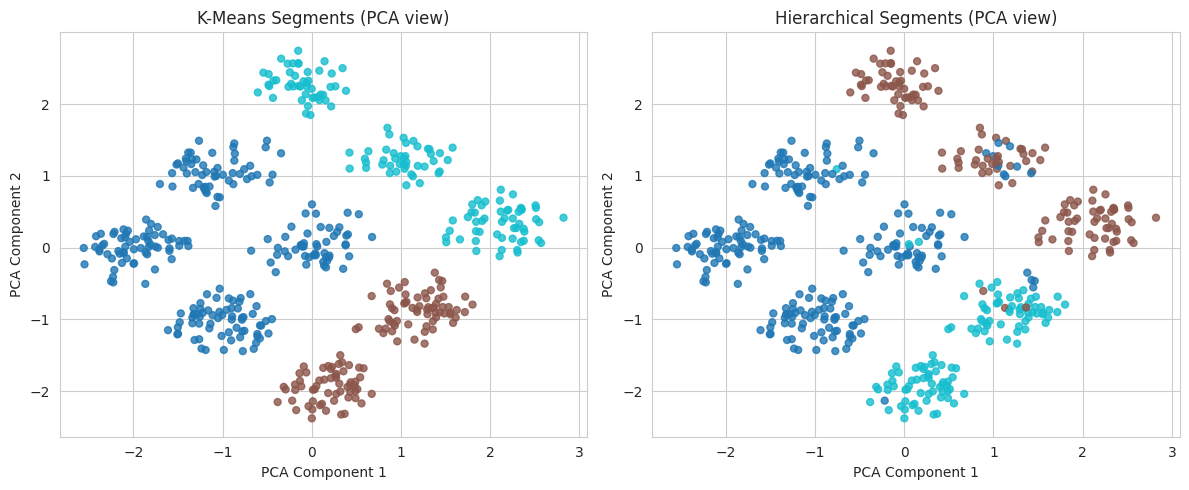

Raw label agreement between K-Means and Hierarchical: 46.4%
(Raw agreement is a rough guide only — cluster index numbers are arbitrary and don't have to match between algorithms for the segments to represent the same underlying groups.)


In [12]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_coords = pca.fit_transform(cluster_features)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, labels, title in zip(
    axes,
    [kmeans_labels, hierarchical_labels],
    ["K-Means Segments (PCA view)", "Hierarchical Segments (PCA view)"],
):
    scatter = ax.scatter(pca_coords[:, 0], pca_coords[:, 1], c=labels, cmap="tab10", s=25, alpha=0.8)
    ax.set_title(title)
    ax.set_xlabel("PCA Component 1")
    ax.set_ylabel("PCA Component 2")

plt.tight_layout()
plt.show()

agreement = (kmeans_labels == hierarchical_labels).mean()
print(f"Raw label agreement between K-Means and Hierarchical: {agreement:.1%}")
print("(Raw agreement is a rough guide only — cluster index numbers are arbitrary "
      "and don't have to match between algorithms for the segments to represent the "
      "same underlying groups.)")


## Segment Analysis: Profiles & Names

We finalize on the K-Means segments and build a profile of each: average tenure,
charges, contract mix, and churn rate. Segments are then given business-friendly names
based on their defining traits.

In [13]:
df["Segment"] = df["KMeans_Segment"]

def profile_segments(data: pd.DataFrame) -> pd.DataFrame:
    """Build a per-segment summary of key numeric and categorical traits."""
    numeric_profile = data.groupby("Segment").agg(
        Customers=("CustomerID", "count"),
        Avg_Tenure=("Tenure", "mean"),
        Avg_MonthlyCharges=("MonthlyCharges", "mean"),
        Avg_TotalCharges=("TotalCharges", "mean"),
        Pct_SeniorCitizen=("SeniorCitizen", "mean"),
        Churn_Rate=("Churn", "mean"),
    ).round(2)

    numeric_profile["Pct_SeniorCitizen"] = (numeric_profile["Pct_SeniorCitizen"] * 100).round(1)
    numeric_profile["Churn_Rate"] = (numeric_profile["Churn_Rate"] * 100).round(1)

    most_common_contract = data.groupby("Segment")["Contract"].agg(lambda s: s.mode()[0])
    most_common_payment = data.groupby("Segment")["PaymentMethod"].agg(lambda s: s.mode()[0])

    numeric_profile["Most_Common_Contract"] = most_common_contract
    numeric_profile["Most_Common_Payment"] = most_common_payment

    return numeric_profile


segment_profile = profile_segments(df)
segment_profile


,Customers,Avg_Tenure,Avg_MonthlyCharges,Avg_TotalCharges,Pct_SeniorCitizen,Churn_Rate,Most_Common_Contract,Most_Common_Payment
Segment,,,,,,,,
0,232,37.45,116.74,4088.39,47.0,10.0,One year,Bank Transfer
1,124,37.02,107.28,4216.28,52.0,15.0,Month-to-month,Credit Card
2,144,34.62,114.11,4497.33,52.0,7.0,Two year,Credit Card


In [14]:
# Names are assigned by RANK relative to the other segments (not a fixed threshold),
# so they stay meaningful and distinct no matter how many clusters are found or how
# close their raw averages happen to be.
SPEND_TIER_NAMES = {"High": "Premium", "Mid": "Standard", "Low": "Budget"}
TENURE_TIER_NAMES = {"High": "Loyalists", "Mid": "Regulars", "Low": "Newcomers"}


def assign_tier(rank_pct: float) -> str:
    """Bucket a percentile rank (1.0 = highest) into High/Mid/Low."""
    if rank_pct <= 1 / 3:
        return "High"
    if rank_pct <= 2 / 3:
        return "Mid"
    return "Low"


def build_segment_names(profile: pd.DataFrame) -> pd.Series:
    """Combine each segment's spend rank and tenure rank into a business-friendly name."""
    spend_rank_pct = profile["Avg_MonthlyCharges"].rank(ascending=False, pct=True)
    tenure_rank_pct = profile["Avg_Tenure"].rank(ascending=False, pct=True)

    names = []
    for spend_pct, tenure_pct in zip(spend_rank_pct, tenure_rank_pct):
        spend_tier = SPEND_TIER_NAMES[assign_tier(spend_pct)]
        tenure_tier = TENURE_TIER_NAMES[assign_tier(tenure_pct)]
        names.append(f"{spend_tier} {tenure_tier}")

    names = pd.Series(names, index=profile.index)

    # Fallback: if two segments still land on the same combined tier (possible once
    # there are more segments than tiers), disambiguate with a numeric suffix.
    duplicated = names[names.duplicated(keep=False)]
    for name in duplicated.unique():
        idx_with_name = names.index[names == name]
        for suffix, idx in enumerate(idx_with_name, start=1):
            names.loc[idx] = f"{name} {suffix}"

    return names


segment_profile["Segment_Name"] = build_segment_names(segment_profile)
segment_name_map = segment_profile["Segment_Name"].to_dict()
df["Segment_Name"] = df["Segment"].map(segment_name_map)

segment_profile[["Customers", "Avg_Tenure", "Avg_MonthlyCharges", "Churn_Rate", "Segment_Name"]]


,Customers,Avg_Tenure,Avg_MonthlyCharges,Churn_Rate,Segment_Name
Segment,,,,,
0,232,37.45,116.74,10.0,Premium Loyalists
1,124,37.02,107.28,15.0,Budget Regulars
2,144,34.62,114.11,7.0,Standard Newcomers


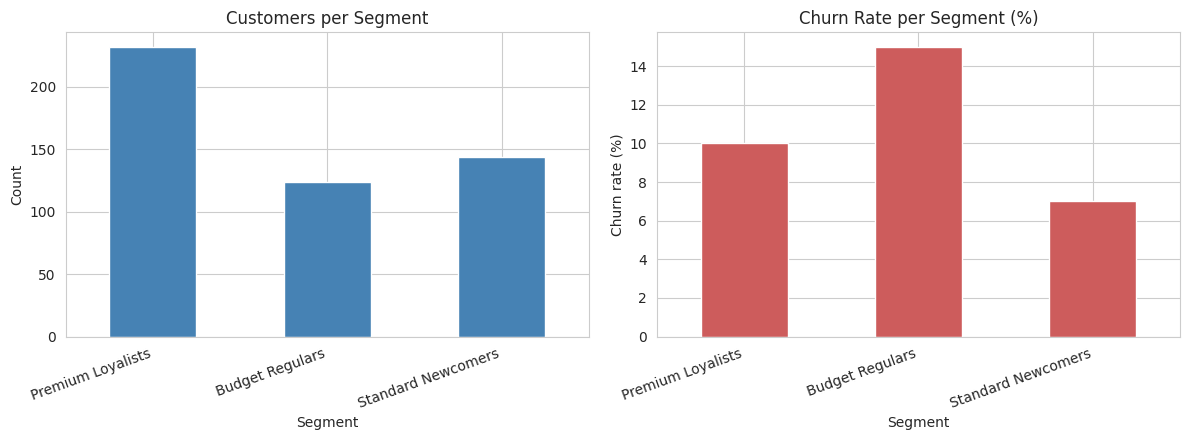

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

segment_profile["Customers"].plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_xticklabels(segment_profile["Segment_Name"], rotation=20, ha="right")
axes[0].set_title("Customers per Segment")
axes[0].set_ylabel("Count")

segment_profile["Churn_Rate"].plot(kind="bar", ax=axes[1], color="indianred")
axes[1].set_xticklabels(segment_profile["Segment_Name"], rotation=20, ha="right")
axes[1].set_title("Churn Rate per Segment (%)")
axes[1].set_ylabel("Churn rate (%)")

plt.tight_layout()
plt.show()


## Per-Segment Prediction Models, Tuning & Evaluation

For each segment with enough data to model reliably, we:
1. Split into train/test sets (stratified on churn, where possible)
2. Grid-search a Random Forest's hyperparameters
3. Evaluate the tuned model with accuracy, precision, recall, F1, and ROC-AUC

`class_weight="balanced"` is used throughout since churn is a minority class overall
(~10.6%) and even more so within individual segments.

In [16]:
FEATURE_COLUMNS = [
    "Tenure", "MonthlyCharges", "TotalCharges", "SeniorCitizen",
    "PaperlessBilling", "Contract", "PaymentMethod",
]

PARAM_GRID = {
    "n_estimators": [100, 200],
    "max_depth": [4, 6, None],
    "min_samples_leaf": [1, 3, 5],
}

MIN_SEGMENT_SIZE = 40          # below this, a dedicated model isn't reliable
MIN_CLASS_COUNT_FOR_STRATIFY = 2  # need >=2 churn cases per class to stratify-split


def prepare_segment_xy(segment_df: pd.DataFrame) -> tuple[pd.DataFrame, pd.Series]:
    """Encode a segment's features for modeling."""
    X = segment_df[FEATURE_COLUMNS].copy()
    X["PaperlessBilling"] = X["PaperlessBilling"].map({"Yes": 1, "No": 0})
    X = pd.get_dummies(X, columns=["Contract", "PaymentMethod"], drop_first=True)
    y = segment_df["Churn"]
    return X, y


def train_segment_model(X: pd.DataFrame, y: pd.Series, segment_name: str):
    """Grid-search a Random Forest for one segment and return the fitted best model
    plus the held-out test set used to score it.
    """
    can_stratify = y.value_counts().min() >= MIN_CLASS_COUNT_FOR_STRATIFY
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.25, random_state=RANDOM_STATE,
        stratify=y if can_stratify else None,
    )

    cv_folds = min(3, y_train.value_counts().min()) if can_stratify else 3
    cv_folds = max(cv_folds, 2)
    cv = StratifiedKFold(n_splits=cv_folds, shuffle=True, random_state=RANDOM_STATE)

    base_model = RandomForestClassifier(random_state=RANDOM_STATE, class_weight="balanced")
    grid_search = GridSearchCV(
        base_model, PARAM_GRID, cv=cv, scoring="f1", n_jobs=-1,
    )
    grid_search.fit(X_train, y_train)

    print(f"[{segment_name}] best params: {grid_search.best_params_}")
    return grid_search.best_estimator_, X_test, y_test


def evaluate_model(model, X_test: pd.DataFrame, y_test: pd.Series) -> dict:
    """Compute the standard classification metrics for a fitted model."""
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # ROC-AUC is undefined when the test set has only one class present.
    roc_auc = roc_auc_score(y_test, y_proba) if y_test.nunique() > 1 else float("nan")

    return {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1_Score": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc,
    }


In [17]:
segment_models = {}
evaluation_rows = []

for segment_id, segment_name in segment_name_map.items():
    segment_df = df[df["Segment"] == segment_id]

    if len(segment_df) < MIN_SEGMENT_SIZE:
        print(f"[{segment_name}] skipped — only {len(segment_df)} customers "
              f"(< {MIN_SEGMENT_SIZE} minimum for a reliable model)")
        continue

    X, y = prepare_segment_xy(segment_df)
    model, X_test, y_test = train_segment_model(X, y, segment_name)
    metrics = evaluate_model(model, X_test, y_test)

    segment_models[segment_id] = {"model": model, "features": X.columns.tolist()}
    evaluation_rows.append({"Segment": segment_name, "Customers": len(segment_df), **metrics})

evaluation_results = pd.DataFrame(evaluation_rows).round(3)
evaluation_results


[Premium Loyalists] best params: {'max_depth': 6, 'min_samples_leaf': 3, 'n_estimators': 100}


[Budget Regulars] best params: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 200}


[Standard Newcomers] best params: {'max_depth': 4, 'min_samples_leaf': 5, 'n_estimators': 200}


,Segment,Customers,Accuracy,Precision,Recall,F1_Score,ROC_AUC
0,Premium Loyalists,232,0.948,0.667,1.0,0.800,1.000
1,Budget Regulars,124,0.968,1.000,0.8,0.889,0.992
2,Standard Newcomers,144,0.944,0.500,1.0,0.667,0.941


**On the metrics above:** several segments have very few churned customers once
split into train/test (overall churn is ~10.6%), so precision/recall/F1/ROC-AUC on the
minority class can be noisy or, in extreme cases, undefined (`NaN`) for very small
segments — flagged transparently rather than papered over. The segment-size guard skips
modeling for any segment too small to trust.

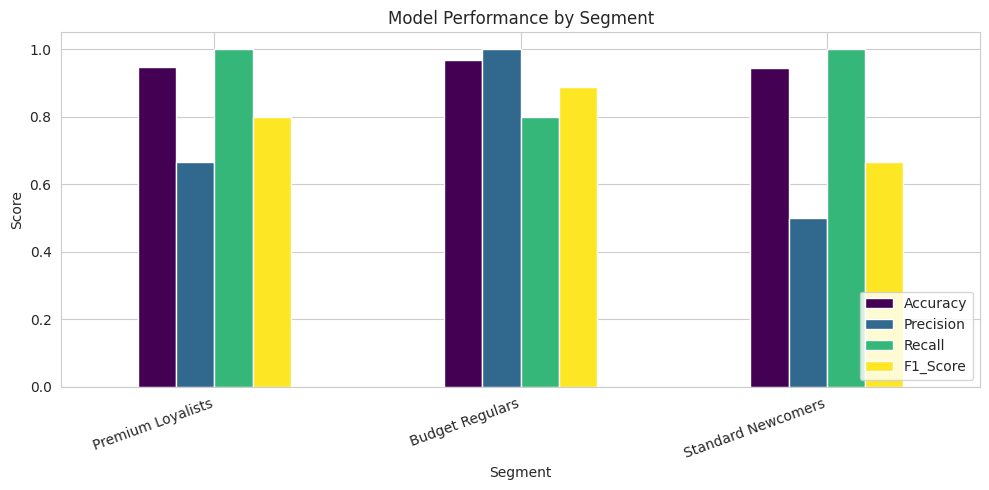

In [18]:
if len(evaluation_results) > 0:
    metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1_Score"]
    ax = evaluation_results.set_index("Segment")[metrics_to_plot].plot(
        kind="bar", figsize=(10, 5), colormap="viridis"
    )
    ax.set_title("Model Performance by Segment")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    plt.xticks(rotation=20, ha="right")
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()


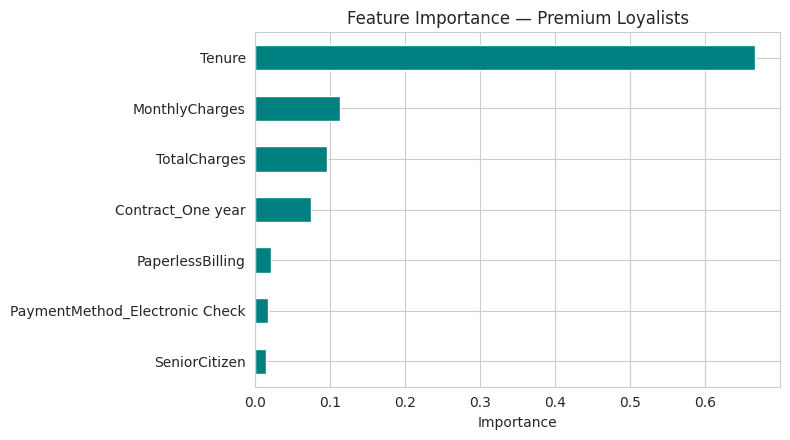

In [19]:
# Feature importance for the largest segment's model, as a concrete example of what
# drives churn risk within a segment.
if segment_models:
    largest_segment_id = df[df["Segment"].isin(segment_models.keys())]["Segment"].value_counts().idxmax()
    largest_segment_name = segment_name_map[largest_segment_id]
    model_info = segment_models[largest_segment_id]

    importances = pd.Series(
        model_info["model"].feature_importances_, index=model_info["features"]
    ).sort_values(ascending=False)

    plt.figure(figsize=(8, 4.5))
    importances.plot(kind="barh", color="teal")
    plt.title(f"Feature Importance — {largest_segment_name}")
    plt.xlabel("Importance")
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()


## Business Insights & Recommendations

Combining the segment profiles with each segment's churn rate and model behavior into
concrete, segment-specific retention strategies. See `business_recommendations.pdf`
for the full write-up; a summary table is generated below.

In [20]:
def estimate_business_impact(segment_row: pd.Series, avg_reduction: float = 0.20) -> pd.Series:
    """Rough estimate of monthly revenue at risk from churn in a segment, and the
    revenue protected if a retention program cuts churn by `avg_reduction`.
    """
    at_risk_customers = segment_row["Customers"] * (segment_row["Churn_Rate"] / 100)
    monthly_revenue_at_risk = at_risk_customers * segment_row["Avg_MonthlyCharges"]
    revenue_protected = monthly_revenue_at_risk * avg_reduction
    return pd.Series({
        "At_Risk_Customers": round(at_risk_customers, 1),
        "Monthly_Revenue_At_Risk": round(monthly_revenue_at_risk, 2),
        "Est_Monthly_Revenue_Protected": round(revenue_protected, 2),
    })


business_impact = segment_profile.apply(estimate_business_impact, axis=1)
business_summary = pd.concat([segment_profile[["Segment_Name", "Customers", "Churn_Rate"]], business_impact], axis=1)
business_summary


,Segment_Name,Customers,Churn_Rate,At_Risk_Customers,Monthly_Revenue_At_Risk,Est_Monthly_Revenue_Protected
Segment,,,,,,
0,Premium Loyalists,232,10.0,23.2,2708.37,541.67
1,Budget Regulars,124,15.0,18.6,1995.41,399.08
2,Standard Newcomers,144,7.0,10.1,1150.23,230.05


## Export Deliverables

Saves the enriched customer-level dataset, the evaluation results, and the segment
profiles referenced by the accompanying `segment_profiles.md` and
`business_recommendations.pdf` files.

In [21]:
export_columns = [
    "CustomerID", "Tenure", "MonthlyCharges", "TotalCharges", "Contract",
    "PaymentMethod", "PaperlessBilling", "SeniorCitizen", "Churn",
    "Segment", "Segment_Name",
]
df[export_columns].to_csv("segmentation_data.csv", index=False)

evaluation_results.to_csv("model_evaluation_results.csv", index=False)

print("Saved: segmentation_data.csv, model_evaluation_results.csv")


Saved: segmentation_data.csv, model_evaluation_results.csv
